In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from pathlib import Path

In [2]:
# ===============================
# 1. LOAD DATA
# ===============================

data_path = Path("data/cfr_progress.csv")
df = pd.read_csv(data_path)

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

# dacă delta lipseste, îl calculăm
if df["delta"].isna().any():
    df["delta"] = df["cumulative"].diff()

df["delta"] = df["delta"].fillna(0)

C:\Users\Mircea\AppData\Local\Temp\ipykernel_3168\1536768116.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["date"] = pd.to_datetime(df["date"])


In [3]:

# ===============================
# 2. LOGISTIC FIT (STRUCTURAL MODEL)
# ===============================

y = df["cumulative"].values
t = np.arange(len(y))

def logistic(t, L, k, t0):
    return L / (1 + np.exp(-k*(t - t0)))

params, _ = curve_fit(logistic, t, y, p0=[100, 0.1, len(y)/2], maxfev=10000)
L, k, t0 = params

next_t = len(y)
logistic_next = logistic(next_t, L, k, t0)

In [4]:

# ===============================
# 3. HOLT-WINTERS ON DELTA
# ===============================

seasonal_period = 12 if len(df) >= 24 else max(2, len(df)//2)

model_hw = ExponentialSmoothing(
    df["delta"],
    trend="add",
    seasonal="add",
    seasonal_periods=seasonal_period
)

fit_hw = model_hw.fit()
holt_next_delta = fit_hw.forecast(1).iloc[0]

In [5]:
# ===============================
# 4. HYBRID COMBINATION
# ===============================

current_cumulative = df["cumulative"].iloc[-1]

# weight crește când ne apropiem de 90%
weight = min(1, current_cumulative / 100)

# logistic produce cumulativ → convertim la delta
logistic_delta = logistic_next - current_cumulative

# combinare
predicted_delta = weight * logistic_delta + (1 - weight) * holt_next_delta
predicted_cumulative = current_cumulative + predicted_delta

# safety cap
if predicted_cumulative > 100:
    predicted_cumulative = 100
    predicted_delta = 100 - current_cumulative

In [6]:
# ===============================
# 5. SAVE FORECAST LOG
# ===============================

forecast_path = Path("output/forecast_log.csv")
forecast_path.parent.mkdir(exist_ok=True)

next_date = df["date"].iloc[-1] + pd.DateOffset(months=1)

forecast_df = pd.DataFrame({
    "date": [next_date],
    "predicted_delta": [predicted_delta],
    "predicted_cumulative": [predicted_cumulative],
    "actual_delta": [np.nan],
    "actual_cumulative": [np.nan],
})

if forecast_path.exists():
    old = pd.read_csv(forecast_path)
    forecast_df = pd.concat([old, forecast_df], ignore_index=True)

forecast_df.to_csv(forecast_path, index=False)

C:\Users\Mircea\AppData\Local\Temp\ipykernel_3168\174790249.py:12: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(start=df["date"].iloc[0], periods=len(future_t), freq="M")


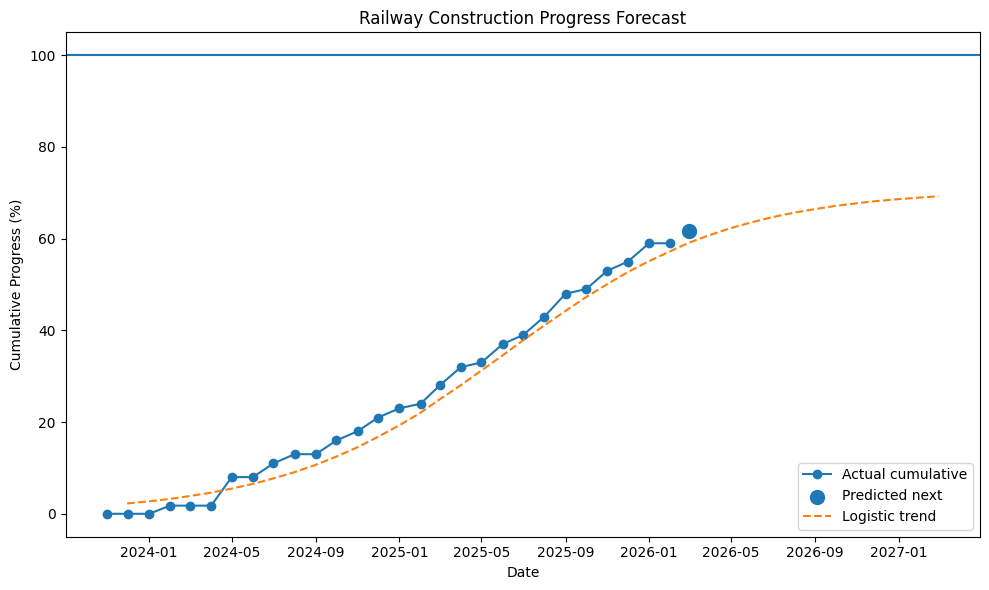

Predicted delta: 2.583
Predicted cumulative: 61.583


In [7]:
# ===============================
# 6. PLOT
# ===============================

plt.figure(figsize=(10,6))

plt.plot(df["date"], df["cumulative"], marker="o", label="Actual cumulative")
plt.scatter(next_date, predicted_cumulative, label="Predicted next", s=100)

# logistic curve smooth
future_t = np.arange(len(y) + 12)
future_dates = pd.date_range(start=df["date"].iloc[0], periods=len(future_t), freq="M")
plt.plot(future_dates, logistic(future_t, L, k, t0), linestyle="--", label="Logistic trend")

plt.axhline(100)
plt.title("Railway Construction Progress Forecast")
plt.xlabel("Date")
plt.ylabel("Cumulative Progress (%)")
plt.legend()
plt.tight_layout()
plt.show()

print("Predicted delta:", round(predicted_delta, 3))
print("Predicted cumulative:", round(predicted_cumulative, 3))